In [37]:
import solver, validator
import file_manager as fm
from theta_vals import theta_sols_C1
import importlib
import numpy as np
import matplotlib.pyplot as plt
import torch

importlib.reload(solver)
importlib.reload(validator)
importlib.reload(fm)

<module 'file_manager' from '/Users/reuter/Documents/Cambridge/SRIM/neural/file_manager.py'>

In [ ]:
theta_amp_initial = np.array([  3.72688684,  -8.66370198,  -4.52485751,  -3.63420301,
         8.39016518,  22.0520419 ,  11.8855687 , -10.07123414,
         6.31198641,  -6.44792308,  -6.88839233,  -5.39316903,
        -3.53666167])


def make_theta_phase_init(
    theta_amp_init,
    p_phase=None,
    perturbation=0.0,
    seed=0,
):
    """
    Initialize the direct phase Ansatz

        omega(V) = exp(log_kappa) * V + x(V)
    
    at, or very close to, fixed phase omega(V)=V.

    Parameter ordering:
        [log_kappa, a0, a, w, b]
    """
    theta_amp_init = np.asarray(
        theta_amp_init,
        dtype=np.float64,
    )

    if (theta_amp_init.size - 1) % 3 != 0:
        raise ValueError(
            "theta_amp_init must have length 1 + 3*p."
        )

    p_amp = (theta_amp_init.size - 1) // 3
    p = p_amp if p_phase is None else int(p_phase)

    if p < 1:
        raise ValueError("p_phase must be positive.")

    # Tanh transition centres distributed across the interval.
    centres = np.linspace(0.15, 0.85, p)

    # Moderate slopes: neither almost linear nor excessively sharp.
    widths = np.linspace(4.0, 12.0, p)

    # w_j V + b_j = 0 at V = centre_j.
    biases = -widths * centres

    rng = np.random.default_rng(seed)

    # Zero gives exactly omega=V.
    # A tiny value such as 1e-4 gives a small symmetry-breaking seed.
    a0 = perturbation * rng.normal()
    a = perturbation * rng.normal(size=p)

    theta_phase_init = np.concatenate([
        np.array([0.0]),  # log_kappa=0, hence kappa=1
        np.array([a0]),
        a,
        widths,
        biases,
    ])

    assert theta_phase_init.size == 3 * p + 2

    return theta_phase_init

theta_phase_initial = np.array([ 2.32026118e-02,  1.38276247e-02,  1.86365318e-02,  2.30379838e-02,
       -5.27642228e-03, -1.16231611e-02,  3.99272956e+00,  6.67027706e+00,
        9.32439296e+00,  1.18731508e+01, -6.83404835e-01, -2.55357464e+00,
       -5.76320983e+00, -1.03325956e+01])
eM_trial = 85

In [27]:
dtype = torch.float64
device = torch.device("cpu")

theta_1 = torch.nn.Parameter(torch.as_tensor(theta_amp_initial, dtype=dtype,device=device).clone())
theta_2 = torch.nn.Parameter(torch.as_tensor(theta_phase_initial, dtype=dtype,device=device).clone())

In [49]:
def objective_C1():
    return solver.loss_C1(theta_1, theta_2, eM_trial, q=1, rho_drho_func=solver.tanh_ansatz, omega_domega_func=solver.omega_domega, n_grid=4001)

In [ ]:
result = solver.adam_optimize(
    parameters=[theta_1, theta_2],
    loss_fn=objective_C1,
    lr=1e-3,
    max_iter=1000,
    loss_tol=1e-16,
    grad_tol=1e-8,
    patience=200,
)

step=    0, loss=1.879266e-10, best=1.879266e-10, |g|=8.955406e-05
step=   20, loss=6.719682e-06, best=1.879266e-10, |g|=1.845834e-02
step=   40, loss=2.246834e-07, best=1.879266e-10, |g|=2.642248e-03
step=   60, loss=7.715866e-08, best=1.879266e-10, |g|=1.957360e-03
step=   80, loss=1.150771e-08, best=1.879266e-10, |g|=7.125496e-04
step=  100, loss=2.154027e-09, best=9.475630e-11, |g|=3.493993e-04
step=  120, loss=3.037055e-10, best=3.064136e-11, |g|=1.277155e-04
step=  140, loss=8.246098e-12, best=4.873914e-14, |g|=1.421870e-05
step=  160, loss=4.308902e-12, best=4.873914e-14, |g|=1.492536e-05
step=  180, loss=1.401629e-13, best=3.758041e-14, |g|=2.598897e-06
step=  200, loss=9.980695e-15, best=9.980695e-15, |g|=5.092242e-07


In [46]:
best_theta_1_torch, best_theta_2_torch = result["best_params"]

best_theta_1 = (best_theta_1_torch.detach().cpu().numpy())
best_theta_2 = (best_theta_2_torch.detach().cpu().numpy())

print("best loss:", result["best_loss"])
print("stop reason:", result["stop_reason"])

best loss: 7.095867198729254e-17
stop reason: loss tolerance reached


In [47]:
validation = validator.validate_C1_scipy(
    theta_amp=best_theta_1,
    theta_phase=best_theta_2,
    eM=85.0,
    q=1.0,
    lam=0.0,
    m_over_e=0.0,
    k=1,
    rho_drho_func=solver.tanh_ansatz,
    omega_domega_func=solver.omega_domega,
    rplus_and_Qtarget_func=solver.rplus_and_Qtarget,
    ansatz_backend="torch",
    n_grid=10001,
    n_profile=10001,
    rtol=1e-11,
    atol=1e-13,
    max_step=2e-3,
    match_tol=1e-7,
    xi_margin=0.0,
    rU_margin=0.0,
)

C1 SCIPY VALIDATION: INVALID

Matching residuals
  Q(1)-Q_target       = +7.750799113637e-09
  Re Phi_U(1)         = -1.205489022882e-05
  Im Phi_U(1)         = -8.276225803794e-06
  residual L2 norm    = 1.462246053368e-05
  largest residual    = 1.205489022882e-05

Admissibility
  inf xi              = +2.098150929457e-03
  sup r_U             = -7.469230215650e-02
  xi condition        = True
  r_U condition       = True

Phase
  omega(1)-omega(0)   = +1.023020850356e+00
  min omega'          = +9.679744582638e-01
  max omega'          = +1.078509358592e+00

Numerics
  grid points         = 10001
  profile points      = 10001
  DOP853 evaluations  = 7532
  interpolated min E  = +6.245823889499e-08
  matching tolerance  = 1.000e-07


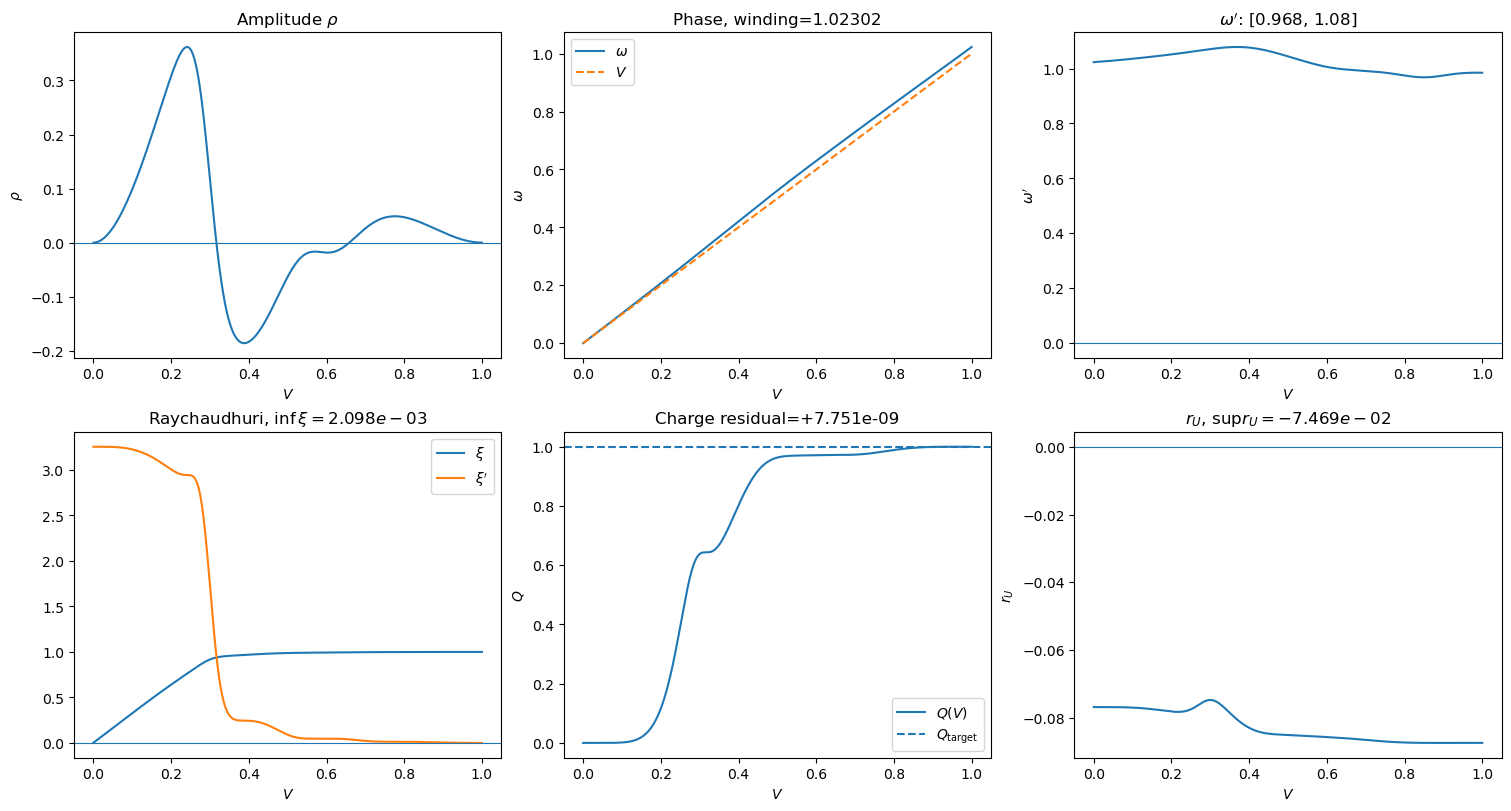

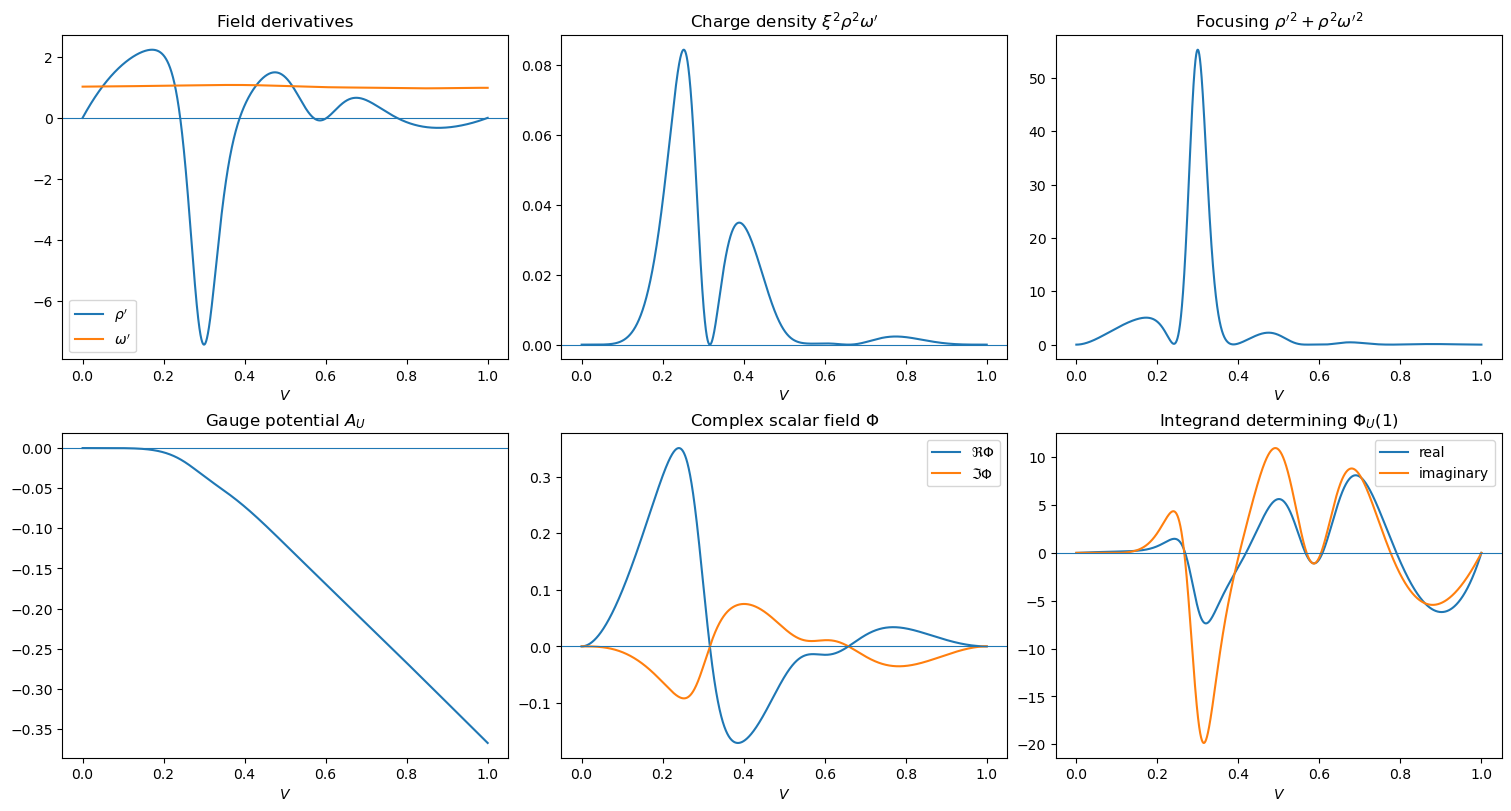

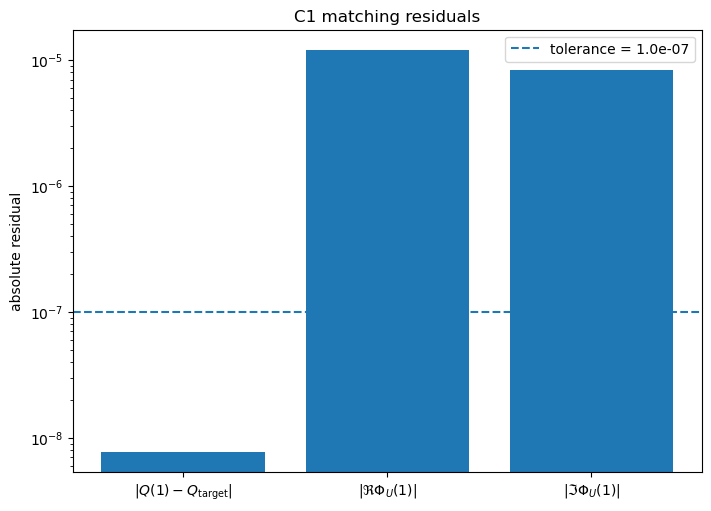

(<Figure size 700x500 with 1 Axes>,
 <Axes: title={'center': 'C1 matching residuals'}, ylabel='absolute residual'>)

In [48]:
validator.print_C1_validation(validation)

validator.plot_C1_profiles(validation)
validator.plot_C1_diagnostics(validation)
validator.plot_C1_residuals(validation)

In [36]:
best_theta_2

array([ 2.32026118e-02,  1.38276247e-02,  1.86365318e-02,  2.30379838e-02,
       -5.27642228e-03, -1.16231611e-02,  3.99272956e+00,  6.67027706e+00,
        9.32439296e+00,  1.18731508e+01, -6.83404835e-01, -2.55357464e+00,
       -5.76320983e+00, -1.03325956e+01])